In [2]:
#Bibliotecas para arquivos
import re
from pathlib import Path
import json

#Para leitura e escrita de dados
import pickle
from collections import defaultdict
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader
from torch.utils.data import Dataset


#Para Imagem
import matplotlib.pyplot as plt

#Normalização
from sklearn.preprocessing import StandardScaler

#Largura de Banda
from scipy.signal import welch
from scipy.signal import butter, filtfilt

#Modelos
from sklearn.model_selection import ParameterGrid
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
import torch
import torch.nn as nn

#Métricas de precisão
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, cohen_kappa_score, accuracy_score
from scipy.stats import spearmanr

#Outros
from tqdm.auto import tqdm
import ast
from itertools import product
from math import prod

#Setar Seed
import random
import os

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [3]:
#HyperParameters

epoch_time = 2


In [4]:
#Leitura Inicial dos Dados

files_csv = list(Path("GAMEEMO").rglob("*.csv"))
files_names = [p.name for p in files_csv]
files_path = [str(p) for p in files_csv]

#Organizacao dos Dados

# procurar por data['SXX']['raw/pre']['GX']
files = defaultdict(lambda: {
    "pre": {},
    "raw": {}
})

for f in files_path:
    subject = re.search(r"S\d{2}", f).group()
    game = re.search(r"G\d", f).group()

    if "AllRawChannels" in f:
        files[subject]["raw"][game] = f
    else:
        files[subject]["pre"][game] = f

files = dict(files)


In [288]:
df = pd.read_csv(files['S01']['pre']['G1'])
df

,AF3,AF4,F3,F4,F7,F8,FC5,FC6,O1,O2,P7,P8,T7,T8,Unnamed: 14
0,-33.02050,-15.184600,-42.1795,1.6872,42.1793,-1.68720,-5.5436,-3.6154,25.7899,-9.88190,5.54360,7.47180,11.8101,17.1128,NaN
1,-28.62910,-20.058300,-42.5410,-10.4653,35.3100,-15.68600,-19.3110,-2.4344,17.4933,3.24420,18.70810,5.09510,17.3683,3.0708,NaN
2,-21.84970,-10.900600,-32.0346,-2.3656,39.6993,-0.64483,-4.0523,-1.0830,26.8081,-3.45840,8.18610,8.40480,15.1209,9.3940,NaN
3,-25.11850,-10.970200,-32.7641,-3.4287,32.7378,4.69650,-8.6299,-1.7412,16.7637,-9.75860,1.18680,0.91086,4.3315,8.1073,NaN
4,-19.03160,-9.588600,-29.1108,-3.9459,35.3533,0.79929,-12.6914,1.0144,13.1068,-0.73692,8.10540,-1.31300,8.1694,8.3442,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38247,-3.44540,5.143000,-13.7038,-5.1667,-7.5078,-4.30370,2.5577,21.9423,5.8066,28.30880,5.71820,-1.37380,-11.0612,-13.8254,NaN
38248,-0.58772,14.234500,-2.5176,9.2433,-2.4780,10.05450,16.5042,6.5258,19.5582,12.51030,-8.72480,12.80860,-12.5673,1.1041,NaN
38249,-7.30110,10.488200,-1.8844,21.8247,-6.6676,23.55120,9.3676,-7.9658,4.2847,-2.34030,-22.30140,3.96570,-8.9205,3.0867,NaN
38250,0.84994,11.304900,-1.2892,6.4152,7.8324,30.33300,20.8569,-1.7034,17.4045,-4.61020,-9.39420,-6.87730,-4.5291,-4.3294,NaN


In [5]:
#EDA
subjects = [f"S{i:02d}" for i in range(1, 29)]
games = [f"G{i}" for i in range(1, 5)]
datakinds = ['pre', 'raw']
window = 50

cmap = plt.get_cmap('tab10')
colors = [cmap(i) for i in range(8)]
color_map = {
    ('G1', 'pre'): colors[0],
    ('G1', 'raw'): colors[1],
    ('G2', 'pre'): colors[2],
    ('G2', 'raw'): colors[3],
    ('G3', 'pre'): colors[4],
    ('G3', 'raw'): colors[5],
    ('G4', 'pre'): colors[6],
    ('G4', 'raw'): colors[7],
}


In [6]:
#Utilização da Frequência

def get_fs():
    df = pd.read_csv(files['S01']['pre']['G1'])
    fs = df.shape[0]//300 +1
    return fs

In [7]:
def simplePlot(column, df, subject, game, datakind):

   fig, ax = plt.subplots()
   ax.plot(df.index, df[column])

   
   ax.set(xlabel='time', ylabel='EEG read',
      title=f'{subject}\'s {column} EEG read through time {game} - {datakind}')
   plt.show()

def comparePlot(column, df, subject, game, datakind):

   df_savgol = pd.DataFrame()
   fig, ax = plt.subplots()
   
   line1, = ax.plot(df.index, df[column])

   line1.set_color(color_map[(game,datakind)])
   line1.set_alpha(0.3)
   ax.set(xlabel='time', ylabel='EEG read (with savgol filter)',
      title=f'{subject}\'s {column} EEG read through time {game} - {datakind}')
   
   df_savgol[f'rolling_{column}'] = df[column].rolling(window=window,min_periods=1).mean()

   line2, = ax.plot(df.index, df[f'rolling_{column}'])
   line2.set_color(color_map[(game,datakind)])
   line2.set_alpha(0.9)
      
   plt.show()

def plotEpochBandPower(column, epoch, subject, game, datakind):
   new_epoch = epoch.reset_index()
   
   fig, (ax1,ax2) = plt.subplots(2,1)

   line1, = ax1.plot(new_epoch.index, new_epoch[column])

   line1.set_color(color_map[(game,datakind)])
   line1.set_alpha(0.9)
   ax1.set(xlabel='epoch time', ylabel='Normalized EEG read',
      title=f'{subject}\'s {column} EEG read through time {game} - {datakind}')
   
   signal = new_epoch[column].values
   fs = get_fs()
   freqs, psd = welch(signal, fs)
   line2, = ax2.plot(freqs, psd)

   line2.set_color('red')
   line2.set_alpha(0.9)
   ax2.set(xlabel='frequency', ylabel='Power',
      title=f'{subject}\'s {column} Power Spectral Density of Power Spectrum of the signal {game} - {datakind}')
   
   plt.subplots_adjust(hspace=0.6)
   plt.show()
   
   


In [8]:
'''col = 'AF3'
for game in games:
    for kind in datakinds:
        comparePlot(col,'S01',kind,game)'''

"col = 'AF3'\nfor game in games:\n    for kind in datakinds:\n        comparePlot(col,'S01',kind,game)"

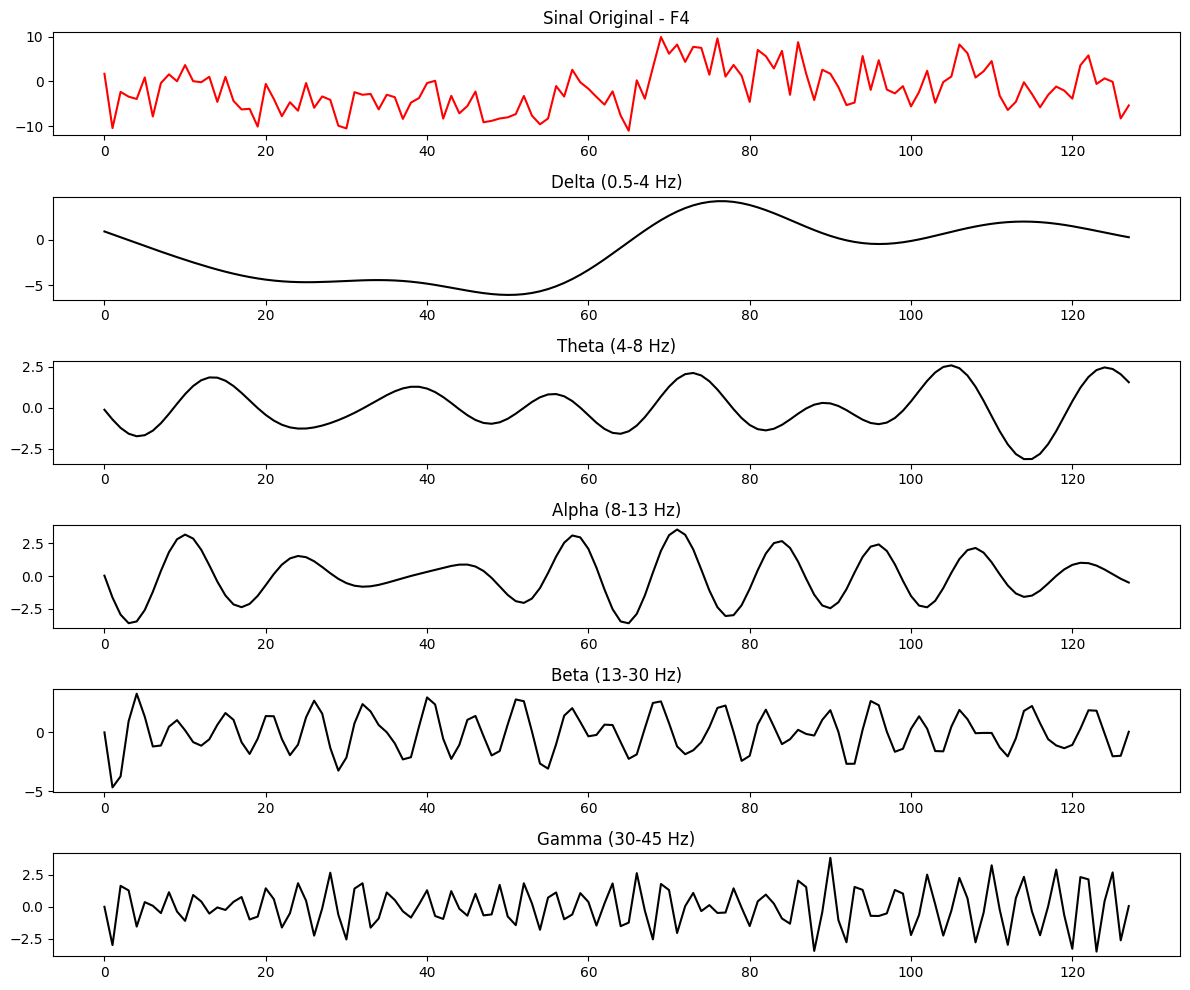

In [9]:
def bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    
    b, a = butter(order, [low, high], btype='band')
    y = filtfilt(b, a, data)
    return y

def plotSbjGameBandPowerXSignal(files, column, subject, game, save=False):
    
    signal = pd.read_csv(files[subject]['pre'][game])[column].iloc[:128]

    fs = 128

    bands = {
        "Delta (0.5-4 Hz)": (0.5, 4),
        "Theta (4-8 Hz)": (4, 8),
        "Alpha (8-13 Hz)": (8, 13),
        "Beta (13-30 Hz)": (13, 30),
        "Gamma (30-45 Hz)": (30, 45)
    }

    filtered_signals = {}

    for name, (low, high) in bands.items():
        filtered_signals[name] = bandpass_filter(signal, low, high, fs)
    
    plt.figure(figsize=(12, 10))

    # Sinal original
    plt.subplot(len(bands)+1, 1, 1)
    plt.plot(signal, color ='red')
    plt.title(f"Sinal Original - {column}")

    # Subplots das bandas
    for i, (name, filtered) in enumerate(filtered_signals.items(), start=2):
        plt.subplot(len(bands)+1, 1, i)
        plt.plot(filtered, color= 'black')
        plt.title(name)
    if save:
        plt.savefig(f"wavefilter.png", dpi=300)
    plt.tight_layout()
    plt.show()

plotSbjGameBandPowerXSignal(files, 'F4', 'S01', 'G1', True)

Limpeza de Dados

In [7]:
#Limpeza

# 1.Re-Referência (CAR)
def CAR(df):
    df_car = df.sub(df.mean(axis=1), axis=0)
    return df_car

# 2. Baseline correction
def base_line(df):
    fs = get_fs()
    baseline_samples = epoch_time * fs
    baseline = df.iloc[:baseline_samples].mean()
    df_base = df - baseline
    return df_base

# 3-1. Normalização por canal
def normalize(df):
    df_norm = df.copy()
    for col in df_norm.columns:
        scaler = StandardScaler()
        df_norm[col] = scaler.fit_transform(df_norm[col].values.reshape(-1,1))
    return df_norm

# 3-2. Normalização por Epoch
def normalize_epoch(epoch):
    return (epoch - epoch.mean()) / epoch.std()

# 4. Epoching
def epoching(df):
    fs = get_fs()
    window = epoch_time * fs
    epochs = []
    for start in range(0, len(df) - window, window):
        epoch = df.iloc[start:start+window]
        epochs.append(epoch)
    return epochs

# 5. Remoção de Artefatos
def remove_artifact(epochs):
    clean_epochs = []
    threshold = 3  # depois do z-score
    for epoch in epochs:
        if epoch.abs().max().max() < threshold:
            clean_epochs.append(epoch)
    return clean_epochs

# 6. Criação dos Nomes das Colunas
def getColumnNames(data, files):
    df = pd.read_csv(files['S01']['pre']['G1'])
    df.dropna(axis=1, how='all', inplace=True)
    channels = df.columns.tolist()
    bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']

    features_names = []
    labels_names = list(data['S01']['G1'].keys())

    for ch in channels:
        for band in bands:
            features_names.append(f"{ch}_{band}")
    
    features_names = features_names + ['male','female','age']

    return features_names,labels_names


## Extração de Features

A extração de Features Foi feita da seguinte forma:

### Divisão em faixas de frequências  para ML Simples

Primeiramente foi feita a divisão dos sinais em 5 faixas de frequências das ondas [1], que variam de acordo com o estado de alerta do indivíduo.

Delta - 0.5 a 4

Theta - 4 a 8

Alpha - 8 a 13

Beta - 13 a 30

Gamma - Maior que 30

### Extração de features demográficas

Foram extraídas informações como gênero (Masculino ou Feminino) e Idade (de 20 a 27 anos).

In [8]:
#Criação de Features

# 1. Largura de Banda
def bandpower(signal, fmin, fmax):
    fs = get_fs()
    freqs, psd = welch(signal, fs)
    idx = np.logical_and(freqs >= fmin, freqs <= fmax)
    
    return np.trapz(psd[idx], freqs[idx])

# 2. Extração de Largura de Banda
def extract_features(epoch):
    features = []

    for col in epoch.columns:
        signal = epoch[col].values

        delta = bandpower(signal, 0.5, 4)
        theta = bandpower(signal, 4, 8)
        alpha = bandpower(signal, 8, 13)
        beta  = bandpower(signal, 13, 30)
        gamma = bandpower(signal, 30, 45)

        features.extend([delta, theta, alpha, beta, gamma])

    return features

# 3-1. Criação de Features com as Larguras de Banda
def feature_creation(clean_epochs):
    X = []

    for epoch in clean_epochs:
        feat = extract_features(epoch)
        X.append(feat)

    X = np.array(X)
    return X

# 3-2. Criação de Features com as Epochs para CNN
def feature_creation_cnn(clean_epochs):
    X = []

    for epoch in clean_epochs:
        feat = epoch.values
        X.append(feat)

    return np.array(X)

# 4-1. Processa um dataframe com as features para Machine Learning Normal
def process_dataframe(df, subject, game):
    
    df = CAR(df)
    df = base_line(df)
    
    epochs = epoching(df)
    clean_epochs = remove_artifact(epochs)
    
    X = []
    tuples = []

    for i, epoch in enumerate(clean_epochs):
        epoch = normalize_epoch(epoch)
        feat = extract_features(epoch)
        tuples.append((subject, game, i+1))            
        X.append(feat)
    return tuples, X

# 4-2. Processa um dataframe com as features para NN
def process_dataframe_cnn(df, subject, game):
    
    df = CAR(df)
    df = base_line(df)
    df = normalize(df)
    
    epochs = epoching(df)
    clean_epochs = remove_artifact(epochs)
    
    X = []
    tuples = []

    for i, epoch in enumerate(clean_epochs):
        feat = epoch.values  # <- aqui muda tudo
        tuples.append((subject, game, i+1))            
        X.append(feat)

    return tuples, np.array(X)

# 5. Extrai as informações do txt
def readGAMEEMOdata():
    with open("gameemodatatxt.txt", "r", encoding="utf-8") as f:
        data = json.load(f)
    return data

# 6. Extrai as labels de um game de um subject
def extract_labels(data, subject, game):
    g = data[subject][game]
    
    return np.array([
        g["satisfied"],
        g["boring"],
        g["horrible"],
        g["calm"],
        g["funny"],
        g["valence"],
        g["arousal"]
    ])

# 7. Encoding do gênero
def encode_gender(g):
    return [0, 1] if g == 1 else [1, 0]

# 8. Normalização da idade
def normalize_age(age, min_age=20, max_age=27):
    return [(age - min_age) / (max_age - min_age)]


# 9-1. Processa todo o dataset, criando as features para Machine Learning Normal 
def build_dataset(files):
    
    data = readGAMEEMOdata()
    X = []
    y = []
    
    tuples = []
    
    colsX, colsy = getColumnNames(data, files)
    
    total_files = sum(
        len(files[s]['pre'])
        for s in files
    )

    with tqdm(total=total_files, desc="Total processing") as pbar:
        for subject in subjects:

            # 🔹 dados demográficos
            gender = data[subject]["gender"]
            age = data[subject]["Age"]
            
            gender_feat = encode_gender(gender)
            age_feat = normalize_age(age)
            demo_features = np.array(gender_feat + age_feat)

            for game in games:
                
                pbar.set_postfix({
                    "Subject": subject,
                    "Game": game,
                })

                df = pd.read_csv(files[subject]['pre'][game])
                df.dropna(axis=1, how='all', inplace=True)
                
                idx_tuple, features_epochs = process_dataframe(df, subject, game)
                tuples.append(idx_tuple)
                # 🔹 labels do jogo
                labels = extract_labels(data, subject, game)
                
                for feat in features_epochs:
                    
                    # X
                    feat = np.concatenate([feat, demo_features])
                    X.append(feat)
                    
                    # y (repete para cada epoch)
                    y.append(labels)
                
                pbar.update(1)
    
    index = pd.MultiIndex.from_tuples(
        tuples,
        names=["subject", "game", "epoch"]
    )

    df_features = pd.DataFrame(X, columns=colsX, index=index)
    df_labels = pd.DataFrame(y, columns=colsy, index=index)
    
    return df_features, df_labels


# 9-2. Processa todo o dataset, criando features para NN
def build_dataset_cnn(files):
    
    data = readGAMEEMOdata()
    
    X_signal = [] 
    X_demo = []
    y = []
    
    tuples = []
    
    total_files = sum(
        len(files[s]['pre'])
        for s in files
    )

    with tqdm(total=total_files, desc="Total processing") as pbar:
        for subject in subjects:

            gender = data[subject]["gender"]
            age = data[subject]["Age"]
            
            gender_feat = encode_gender(gender)
            age_feat = normalize_age(age)
            demo_features = np.array(gender_feat + age_feat)

            for game in games:
                
                pbar.set_postfix({
                    "Subject": subject,
                    "Game": game,
                })

                df = pd.read_csv(files[subject]['pre'][game])
                df.dropna(axis=1, how='all', inplace=True)
                
                idx_tuple, epochs = process_dataframe_cnn(df, subject, game)
                tuples.extend(idx_tuple)
                
                labels = extract_labels(data, subject, game)
                
                for epoch in epochs:
                    
                    X_signal.append(epoch)
                    X_demo.append(demo_features)
                    y.append(labels)
                
                pbar.update(1)

    return (np.array(X_signal), np.array(X_demo), np.array(y), tuples)

In [9]:
def save_dataset(folder, X_signal, X_demo, y, tuples):
    
    df = pd.read_csv(files['S01']['pre']['G1'])
    df.dropna(axis=1, how='all', inplace=True)
    colsX = df.columns.tolist()
    
    data = readGAMEEMOdata()
    folder = Path(folder)
    folder.mkdir(parents=True, exist_ok=True)

    np.savez(
        folder / "dataset_eeg.npz",
        X_signal=X_signal,
        X_demo=X_demo,
        y=y
    )

    meta_df = pd.DataFrame(tuples, columns=["subject", "game", "epoch"])
    
    labels_names = list(data['S01']['G1'].keys())
    for i, name in enumerate(labels_names):
        meta_df[name] = y[:, i]

    meta_df.to_csv(folder / "metadata.csv", index=False)

    with open(folder / "channels.json", "w") as f:
        json.dump(colsX, f)

    print(f"Dataset salvo em: {folder.resolve()}")

In [12]:
#Leitura de Labels

folder_name = 'dataset_cnn'

#df_features, df_labels = build_dataset(files)

#df_features.to_pickle('features_SML.pkl')
#df_labels.to_pickle('labels_SML.pkl')

X_signal, X_demo, y, tuples = build_dataset_cnn(files)

save_dataset(folder_name, X_signal, X_demo, y, tuples)

Total processing:   0%|          | 0/112 [00:00<?, ?it/s]

Dataset salvo em: C:\Users\mathe\Desktop\Kaggle\GAMEEMO\dataset_cnn


Divisão de Dados

In [ ]:
df_features = pd.read_pickle('features_SML.pkl')
df_labels = pd.read_pickle('labels_SML.pkl')

Feature Engineering

Teoria da Assimetria Frontal

In [ ]:
def frontalAssymetry(df):
    asym_pairs = [
        ("AF3", "AF4"),
        ("F3", "F4"),
        ("F7", "F8"),
    ]

    for ch_left, ch_right in asym_pairs:
        for band in ["alpha", "beta", "theta"]:
            col_l = f"{ch_left}_{band}"
            col_r = f"{ch_right}_{band}"
            
            if col_l in df.columns and col_r in df.columns:
                df[f"{ch_left}{ch_right}_{band}_asym"] = df[col_l] - df[col_r]
    return df

Band Ratio

In [ ]:
def bandRatio(df):
    
    ratio_pairs = [
        ("alpha", "beta"),
        ("theta", "beta"),
        ("alpha", "theta")
    ]

    important_channels = ["AF3", "AF4", "F3", "F4"]

    for ch in important_channels:
        for b1, b2 in ratio_pairs:
            col1 = f"{ch}_{b1}"
            col2 = f"{ch}_{b2}"
            
            if col1 in df.columns and col2 in df.columns:
                df[f"{ch}_{b1}_{b2}_ratio"] = df[col1] / (df[col2] + 1e-6)
    
    return df

Frontal vs Occipital

In [ ]:
def frontalvsOccipital(df):
    frontal = ["F3", "F4", "AF3", "AF4"]
    occipital = ["O1", "O2"]

    for band in ["alpha", "beta", "theta"]:
        
        frontal_cols = [f"{ch}_{band}" for ch in frontal if f"{ch}_{band}" in df.columns]
        occipital_cols = [f"{ch}_{band}" for ch in occipital if f"{ch}_{band}" in df.columns]
        
        if frontal_cols and occipital_cols:
            df[f"frontal_occipital_{band}"] = (
                df[frontal_cols].mean(axis=1) - df[occipital_cols].mean(axis=1)
            )
    return df

Important Channels Variation

In [1]:
def createLOSOSplit(features, labels, test_subject, target, seed, n_epochs, remove_demo = False):
    if remove_demo:
        features = features.drop(['male','female','age'], axis=1)

    X_test = features.xs(test_subject, level=0)
    y_test = labels.xs(test_subject, level=0)[target]

    X_train = features.drop(test_subject, level=0)
    y_train = labels.drop(test_subject, level=0)[target]

    def sample_df(X, y):
        df = X.copy()
        df[target] = y.values
        df = (
            df
            .groupby(level=[0,1], group_keys=False)  # Game
            .apply(lambda x: x.sample(n=min(len(x), n_epochs),random_state=seed))
        )
        
        y_sampled = df[target].values
        X_sampled = df.drop(columns=[target]).values
        
        return X_sampled, y_sampled

    X_train, y_train = sample_df(X_train, y_train)
    X_test, y_test   = sample_df(X_test, y_test)

    return np.array(X_train), np.array(y_train), np.array(X_test), np.array(y_test)

def LOSOCV(model, features, labels, metric_list, seed=13, n_epochs=40, remove_demo=False, test_subjects = subjects):
    
    dfs = {}

    metrics = {}
    for target in tqdm(labels.columns, desc="Targets", leave=False):

        results_subject = {}
        metrics_target = {}
        
        subjects_bar = tqdm(np.unique(test_subjects), desc="Subjects", leave=False)

        for test_subject in subjects_bar:

            subjects_bar.set_postfix({
            "target": target,
            "subject": test_subject
            })
            
            results_subject[test_subject] = {}

            #Com ajuste para caso std não zere
            features = features.groupby(level=0).apply(
                lambda x: (x - x.mean()) / (x.std() + 1e-8)
            )

            X_train, y_train, X_test, y_test = createLOSOSplit(features, labels, test_subject, target, seed=seed, n_epochs=n_epochs, remove_demo=remove_demo)
            
            model_fold = clone(model)

            model_fold.fit(X_train, y_train)
            y_pred = np.clip(np.round(model_fold.predict(X_test)), 1,10)
            
            for metric in metric_list:
                if metric == "accuracy":
                    results_subject[test_subject]["accuracy"] = accuracy_score(y_test, y_pred)
                if metric == "mae":
                    results_subject[test_subject]["mae"] = mean_absolute_error(y_test, y_pred)
                if metric == "rmse":
                    results_subject[test_subject]["rmse"] = np.sqrt(mean_squared_error(y_test, y_pred))
                if metric == "r2":
                    results_subject[test_subject]["r2"] = r2_score(y_test, y_pred)
                if metric == "qwk":
                    results_subject[test_subject]["qwk"] = cohen_kappa_score(y_test, np.round(y_pred), weights='quadratic')
                if metric == "spearmanr":
                    if np.std(y_pred) == 0:
                        results_subject[test_subject]["spearmanr"] = 0
                    elif np.std(y_test) == 0:
                        results_subject[test_subject]["spearmanr"] = 0
                    else:
                        results_subject[test_subject]["spearmanr"] = spearmanr(y_test, y_pred)[0]

        results_df = pd.DataFrame.from_dict(results_subject, orient='index')
        dfs[target] = results_df
        
        for metric in metric_list:
            metrics_target[metric] = {}
            values = [results_subject[s][metric] for s in results_subject]
            metrics_target[metric]['mean'] = np.mean(values)
            metrics_target[metric]['std'] = np.std(values)
        metrics[target] = metrics_target
    return dfs, metrics


NameError: name 'subjects' is not defined

Criação do Modelo ML Normal

In [ ]:
xgb_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.1],
    "max_depth": [3, 6]
}

rf_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, None]
}

knn_grid = {
    "n_neighbors": [3, 5, 7]
}

grids = {
    "XGB": xgb_grid,
    "RF": rf_grid,
    "KNN": knn_grid
}
seeds = [13,44,71]
base_models = {
    "XGB": XGBRegressor(objective='reg:squarederror', eval_metric = 'mae'),
    "RF": RandomForestRegressor(),
    "KNN": KNeighborsRegressor()
}

metrics_all = {}
results_all = {}

metric_list = ["mae", 'accuracy', "qwk", "spearmanr"]
total_grid = sum(len(list(ParameterGrid(grid))) for grid in grids.values())

#Simple ML
with tqdm(total=total_grid, desc="Total processing") as pbar:
    for model_name in base_models:
        
        base_model = base_models[model_name]

        pbar.set_description(f"modelo atual {model_name}") 

        for params in ParameterGrid(grids[model_name]):

            for seed in seeds:

                pbar.set_postfix({
                    "model": model_name,
                    "seed": seed
                })

                set_seed(seed)

                model = clone(base_model)
                model.set_params(**params)

                dfs, metrics = LOSOCV(
                    model,
                    df_features,
                    df_labels,
                    metric_list,
                    seed=seed
                )

                key = f"{model_name}_{params}_seed{seed}"

                results_all[key] = dfs
                metrics_all[key] = metrics

            pbar.update(1)



Total processing:   0%|          | 0/19 [00:00<?, ?it/s]

Targets:   0%|          | 0/7 [00:00<?, ?it/s]

Subjects:   0%|          | 0/28 [00:00<?, ?it/s]

Subjects:   0%|          | 0/28 [00:00<?, ?it/s]

Exception ignored in: <function tqdm.__del__ at 0x00000205800B96C0>
Traceback (most recent call last):
  File "c:\Users\mathe\anaconda3\Lib\site-packages\tqdm\std.py", line 1148, in __del__
    self.close()
  File "c:\Users\mathe\anaconda3\Lib\site-packages\tqdm\notebook.py", line 272, in close
    def close(self):

KeyboardInterrupt: 


Subjects:   0%|          | 0/28 [00:00<?, ?it/s]

In [132]:
def format_model_name(model_str):
    
    if "_seed" in model_str:
        base, seed_part = model_str.rsplit("_seed", 1)
        seed = seed_part
    else:
        base = model_str
        seed = None

    model, params_str = base.split("_", 1)
    
    params = ast.literal_eval(params_str)
    
    rename_map = {
        "n_filters": "filters",
        "kernel_size": "krnlsize",
        "hidden_dim": "hidden",
        "num_layers": "layers",
        "lr": "lr",
        "learning_rate": "lr",
        "n_neighbors": "neigh",
        "max_depth": "depth",
        "n_estimators": "ests"
    }
    
    parts = [model]
    
    for key, value in params.items():
        new_key = rename_map.get(key, key)
        
        if isinstance(value, float):
            value = str(value).replace(".", "_")
        
        parts.append(f"{new_key}_{value}")

    if seed is not None:
        parts.append(f"seed_{seed}")
    
    return "_".join(parts)


In [97]:
results_all.keys()

dict_keys(["XGB_{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}_seed13", "XGB_{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}_seed44", "XGB_{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}_seed71", "XGB_{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}_seed13", "XGB_{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}_seed44", "XGB_{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}_seed71", "XGB_{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300}_seed13", "XGB_{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300}_seed44", "XGB_{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300}_seed71", "XGB_{'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 100}_seed13", "XGB_{'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 100}_seed44", "XGB_{'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 100}_seed71", "XGB_{'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 200}_seed13", "XGB_{'learnin

In [133]:
output_dir = Path("Models")
output_dir.mkdir(parents=True, exist_ok=True)

for model in results_all.keys():
    model_name = format_model_name(model)
    print(model_name)
    file_path = output_dir / f"{model_name}.xlsx"
    with pd.ExcelWriter(file_path) as writer:
        for target in results_all[model].keys():
            results_all[model][target].to_excel(
                writer, 
                sheet_name=str(target)
            )



XGB_lr_0_01_depth_3_ests_100_seed_13
XGB_lr_0_01_depth_3_ests_100_seed_44
XGB_lr_0_01_depth_3_ests_100_seed_71
XGB_lr_0_01_depth_3_ests_200_seed_13
XGB_lr_0_01_depth_3_ests_200_seed_44
XGB_lr_0_01_depth_3_ests_200_seed_71
XGB_lr_0_01_depth_3_ests_300_seed_13
XGB_lr_0_01_depth_3_ests_300_seed_44
XGB_lr_0_01_depth_3_ests_300_seed_71
XGB_lr_0_01_depth_6_ests_100_seed_13
XGB_lr_0_01_depth_6_ests_100_seed_44
XGB_lr_0_01_depth_6_ests_100_seed_71
XGB_lr_0_01_depth_6_ests_200_seed_13
XGB_lr_0_01_depth_6_ests_200_seed_44
XGB_lr_0_01_depth_6_ests_200_seed_71
XGB_lr_0_01_depth_6_ests_300_seed_13
XGB_lr_0_01_depth_6_ests_300_seed_44
XGB_lr_0_01_depth_6_ests_300_seed_71
XGB_lr_0_1_depth_3_ests_100_seed_13
XGB_lr_0_1_depth_3_ests_100_seed_44
XGB_lr_0_1_depth_3_ests_100_seed_71
XGB_lr_0_1_depth_3_ests_200_seed_13
XGB_lr_0_1_depth_3_ests_200_seed_44
XGB_lr_0_1_depth_3_ests_200_seed_71
XGB_lr_0_1_depth_3_ests_300_seed_13
XGB_lr_0_1_depth_3_ests_300_seed_44
XGB_lr_0_1_depth_3_ests_300_seed_71
XGB_lr_0_1

Criação de Modelo NN

In [104]:
class EEGDataset(Dataset):
    def __init__(self, X_signal, X_demo, y):
        self.X_signal = torch.tensor(X_signal, dtype=torch.float32)
        self.X_demo = torch.tensor(X_demo, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_signal[idx], self.X_demo[idx], self.y[idx]

class CNN1D(nn.Module):
    def __init__(self, in_channels, demo_dim, n_outputs, n_filters=32, kernel_size=3, hidden_dim=64):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(in_channels, n_filters, kernel_size),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(n_filters, n_filters*2, kernel_size),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.AdaptiveAvgPool1d(1)
        )
        
        self.flatten = nn.Flatten()

        self.fc_signal = nn.Linear(n_filters * 2, hidden_dim)
        self.fc_demo = nn.Linear(demo_dim, 16)

        self.fc = nn.Sequential(
            nn.ReLU(),
            nn.Linear(hidden_dim + 16, n_outputs)
        )

    def forward(self, x_signal, x_demo):

        x = x_signal.permute(0, 2, 1) 
        x = self.conv(x)
        x = self.flatten(x)
        x = self.fc_signal(x)

        d = self.fc_demo(x_demo)

        x = torch.cat([x, d], dim=1)
        return self.fc(x)

class LSTMModel(nn.Module):
    def __init__(self, input_dim, demo_dim, hidden_dim, num_layers, n_outputs):
        super().__init__()

        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)

        self.fc_demo = nn.Linear(demo_dim, 16)

        self.fc = nn.Sequential(
            nn.Linear(hidden_dim + 16, 64),
            nn.ReLU(),
            nn.Linear(64, n_outputs)
        )

    def forward(self, x_signal, x_demo):
        out, _ = self.lstm(x_signal)
        x = out[:, -1, :]  

        d = self.fc_demo(x_demo)

        x = torch.cat([x, d], dim=1)
        return self.fc(x)

class GRUModel(nn.Module):
    def __init__(self, input_dim, demo_dim, hidden_dim, num_layers, n_outputs):
        super().__init__()

        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True)

        self.fc_demo = nn.Linear(demo_dim, 16)

        self.fc = nn.Sequential(
            nn.Linear(hidden_dim + 16, 64),
            nn.ReLU(),
            nn.Linear(64, n_outputs)
        )

    def forward(self, x_signal, x_demo):
        out, _ = self.gru(x_signal)
        x = out[:, -1, :]

        d = self.fc_demo(x_demo)

        x = torch.cat([x, d], dim=1)
        return self.fc(x)

def fitpredict(model, train_loader, test_loader, epochs=10, lr=1e-3):

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = torch.nn.MSELoss()

    model.train()
    for _ in range(epochs):
        for xs, xd, y in train_loader:
            optimizer.zero_grad()
            pred = model(xs, xd).squeeze(-1)
            loss = criterion(pred, y)
            loss.backward()
            optimizer.step()

    model.eval()
    preds = []
    targets = []

    with torch.no_grad():
        for xs, xd, y in test_loader:
            pred = np.round(model(xs, xd).squeeze(-1))
            pred = pred.view(-1)
            y = y.view(-1)
            preds.extend(pred.cpu().numpy())
            targets.extend(y.cpu().numpy())

    return np.array(targets), np.array(preds)

def computeMetrics(y_true, y_pred, metric_list):
    
    results = {}

    for metric in metric_list:
        if metric == "mae":
            results["mae"] = mean_absolute_error(y_true, y_pred)

        elif metric == "rmse":
            results["rmse"] = np.sqrt(mean_squared_error(y_true, y_pred))

        elif metric == "r2":
            results["r2"] = r2_score(y_true, y_pred)

        elif metric == "qwk":
            results["qwk"] = cohen_kappa_score(
                y_true, y_pred, weights="quadratic"
            )
        elif metric == "spearmanr":
            if np.std(y_pred)==0:
                results["spearmanr"]=0
            else:
                results["spearmanr"] = spearmanr(y_true, y_pred)[0]

    return results

def createLOSOSplitNN(X_signal, X_demo, y, test_subject, target_idx, seed=13, n_epochs = 5):
    
    meta_df = pd.read_csv('dataset_cnn/metadata.csv')
    subjects = meta_df["subject"].values
    
    meta_df = meta_df.reset_index(drop=True)


    train_mask = meta_df["subject"] != test_subject
    test_mask  = meta_df["subject"] == test_subject

    meta_train = meta_df[train_mask]
    meta_test  = meta_df[test_mask]

    def sample_indices(meta):
        return (
            meta.groupby(["subject", "game"], group_keys=False)
                .apply(lambda x: x.sample(
                    n=min(len(x), n_epochs),
                    random_state=seed
                ), include_groups=False)
                .index
        )
    
    train_idx = sample_indices(meta_train)
    test_idx  = sample_indices(meta_test)
    
    return ( X_signal[train_idx], X_demo[train_idx], y[train_idx][:, target_idx],
        X_signal[test_idx], X_demo[test_idx], y[test_idx][:, target_idx],
    )

def LOSOCV_NN(
    model_class,
    model_params,
    X_signal,
    X_demo,
    y,
    metric_list,
    lr=1e-3,
    epochs_num=10,
    batch_size=32,
    seed=13,
    n_epochs=5,
):
    subjects = [f"S{i:02d}" for i in range(1, 29)]

    dfs = {}
    metrics = {}
    target_names = pd.read_csv("dataset_cnn/metadata.csv").columns.tolist()[3:]

    for target_idx, target in enumerate(tqdm(target_names, desc="Targets", leave=False)):

        results_subject = {}
        metrics_target = {}
        
        subjects_bar = tqdm(np.unique(subjects), desc="Subjects", leave=False)

        for test_subject in subjects_bar:
            
            subjects_bar.set_postfix({
            "target": target,
            "subject": test_subject
            })

            X_tr_s, X_tr_d, y_tr, X_te_s, X_te_d, y_te = createLOSOSplitNN(
                X_signal, X_demo, y, test_subject, target_idx, seed=seed, n_epochs=n_epochs
            )

            train_ds = EEGDataset(X_tr_s, X_tr_d, y_tr)
            test_ds  = EEGDataset(X_te_s, X_te_d, y_te)
            
            train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
            test_loader  = DataLoader(test_ds, batch_size=batch_size)

            model = model_class(**model_params)
            
            y_true, y_pred = fitpredict(
                model, train_loader, test_loader, epochs=epochs_num, lr=lr
            )

            results_subject[test_subject] = computeMetrics(
                y_true, y_pred, metric_list
            )

        results_df = pd.DataFrame.from_dict(results_subject, orient="index")
        dfs[target] = results_df

        for metric in metric_list:
            values = results_df[metric].values
            metrics_target[metric] = {
                "mean": np.mean(values),
                "std": np.std(values)
            }

        metrics[target] = metrics_target

    return dfs, metrics

In [ ]:
def expand_grid(grid):
    keys = list(grid.keys())
    values = list(grid.values())
    
    for combo in product(*values):
        yield dict(zip(keys, combo))

metric_list = ["mae", "rmse", "r2", "qwk", "spearmanr"]

cnn_grid = {
    "n_filters": [32],
    "kernel_size": [3, 5],
    "lr": [1e-3, 1e-4]
}



data = np.load("dataset_cnn/dataset_eeg.npz")

X_signal = data["X_signal"]
X_demo   = data["X_demo"]
y        = data["y"]


models_config = {
    "CNN": (CNN1D, cnn_grid)
    #"LSTM": (LSTMModel, rnn_grid),
    #"GRU": (GRUModel, rnn_grid)
}

total_grid = sum(
    prod(len(v) for v in grid.values())
    for _, (_, grid) in models_config.items()
)
with tqdm(total=total_grid, desc="Total processing") as pbar:

    for model_name, (model_class, grid) in models_config.items():

        for params in expand_grid(grid):  # 🔥 AQUI

            for seed in seeds:

                pbar.set_postfix({
                    "model": model_name,
                    "params": str(params),
                    "seed": seed
                })

                set_seed(seed)

                model_params = params.copy()
                lr = model_params.pop("lr")

                if model_name == "CNN":
                    model_params.update({
                        "in_channels": X_signal.shape[2],
                        "demo_dim": X_demo.shape[1],
                        "n_outputs": 1
                    })

                dfs, metrics = LOSOCV_NN(
                    model_class=model_class,
                    model_params=model_params,
                    X_signal=X_signal,
                    X_demo=X_demo,
                    y=y,
                    metric_list=metric_list,
                    lr=lr,
                    epochs_num=10,
                    batch_size=32,
                    seed=seed
                )

                key = f"{model_name}_{params}_seed{seed}"

                results_all[key] = dfs
                metrics_all[key] = metrics

            pbar.update(1)

Total processing:   0%|          | 0/2 [00:00<?, ?it/s]

Targets:   0%|          | 0/7 [00:00<?, ?it/s]

Subjects:   0%|          | 0/28 [00:00<?, ?it/s]

Subjects:   0%|          | 0/28 [00:00<?, ?it/s]

Subjects:   0%|          | 0/28 [00:00<?, ?it/s]

...

Subjects:   0%|          | 0/28 [00:00<?, ?it/s]

Subjects:   0%|          | 0/28 [00:00<?, ?it/s]

Subjects:   0%|          | 0/28 [00:00<?, ?it/s]

Subjects:   0%|          | 0/28 [00:00<?, ?it/s]

Subjects:   0%|          | 0/28 [00:00<?, ?it/s]

In [108]:
output_dir = Path("Models")
output_dir.mkdir(parents=True, exist_ok=True)

for model_name, (model_class, grid) in models_config.items():
    for params in expand_grid(grid):
        key = f"{model_name}_{params}_seed{seed}"
        file_name = format_model_name(key)
        print(file_name)
        break
        file_path = output_dir / f"{file_name}.xlsx"

        with pd.ExcelWriter(file_path) as writer:
            for target in results_all[key].keys():
                results_all[key][target].to_excel(
                    writer, 
                    sheet_name=str(target)
                )

CNN_filters_32_krnlsize_3_lr_0_0001_seed_71


Experimento de Ablação

In [134]:
def load_results(folder_path="."):
    results_all = {}

    for file in Path(folder_path).glob("*.xlsx"):

        model_name = file.stem  
        if file.name.startswith("~$"):
            continue
        
        sheets = pd.read_excel(file,index_col=0, sheet_name=None)
        
        
        results_all[model_name] = sheets
    return results_all

def get_metrics(results):

    metrics = {}
    
    for model in results.keys():
        metrics[model]={}

        for target in results[model].keys():

            metrics[model][target] = {}

            for metric in results[model][target].columns:
                metrics[model][target][metric] = {}
                values = results[model][target][metric].values
                metrics[model][target][metric]['mean'] = np.mean(values)
                metrics[model][target][metric]['std'] = np.std(values)

    return metrics

results_loaded = load_results('Models')
metrics_loaded = get_metrics(results_loaded)

In [137]:
from collections import defaultdict

def groupBySeed(metrics_loaded):
    grouped = defaultdict(list)

    for model_name, targets in metrics_loaded.items():
        
        if "_seed_" in model_name:
            base_name = model_name.split("_seed_")[0]
        else:
            base_name = model_name
        
        grouped[base_name].append(targets)

    return grouped

def averageMetrics(grouped_metrics):
    
    aggregated = {}

    for base_model, runs in grouped_metrics.items():
        
        aggregated[base_model] = {}

        for target in runs[0].keys():
            
            aggregated[base_model][target] = {}

            for metric in runs[0][target].keys():
                
                values = [
                    run[target][metric]["mean"]
                    for run in runs
                ]

                aggregated[base_model][target][metric] = {
                    "mean": np.mean(values),
                    "std": np.std(values)
                }

    return aggregated

def getTopK(metrics_agg, k=5):
    
    top_k_per_target = {}

    # pegar lista de targets
    targets = list(next(iter(metrics_agg.values())).keys())

    for target in targets:
        
        ranking = []

        for model, target_metrics in metrics_agg.items():
            
            qwk_mean = target_metrics[target]["qwk"]["mean"]
            qwk_std  = target_metrics[target]["qwk"]["std"]

            ranking.append({
                "model": model,
                "mean": qwk_mean,
                "std": qwk_std
            })

        # ordenar
        ranking = sorted(ranking, key=lambda x: x["mean"], reverse=True)

        top_k_per_target[target] = ranking[:k]

    return top_k_per_target

In [138]:
top_k = 5

grouped = groupBySeed(metrics_loaded)
metrics_avg = averageMetrics(grouped)

top5 = getTopK(metrics_avg, k=top_k)
for target in top5:
    print('\n',target,'\n')
    for i in range(len(top5[target])):

        print(f"{top5[target][i]['model']} → QWK: {top5[target][i]['mean']:.4f} ± {top5[target][i]['std']:.4f}")



 satisfied 

KNN_neigh_3 → QWK: 0.2592 ± 0.0177
XGB_lr_0_1_depth_6_ests_200 → QWK: 0.2587 ± 0.0198
XGB_lr_0_1_depth_6_ests_300 → QWK: 0.2584 ± 0.0202
XGB_lr_0_1_depth_6_ests_100 → QWK: 0.2530 ± 0.0186
XGB_lr_0_1_depth_3_ests_300 → QWK: 0.2509 ± 0.0103

 boring 

XGB_lr_0_1_depth_3_ests_300 → QWK: 0.4101 ± 0.0410
XGB_lr_0_1_depth_3_ests_200 → QWK: 0.3977 ± 0.0339
XGB_lr_0_1_depth_6_ests_200 → QWK: 0.3969 ± 0.0177
XGB_lr_0_1_depth_6_ests_300 → QWK: 0.3967 ± 0.0184
XGB_lr_0_1_depth_6_ests_100 → QWK: 0.3952 ± 0.0189

 horrible 

KNN_neigh_3 → QWK: 0.4179 ± 0.0451
XGB_lr_0_1_depth_6_ests_300 → QWK: 0.4008 ± 0.0203
XGB_lr_0_1_depth_6_ests_200 → QWK: 0.3994 ± 0.0199
XGB_lr_0_1_depth_6_ests_100 → QWK: 0.3834 ± 0.0226
XGB_lr_0_1_depth_3_ests_300 → QWK: 0.3800 ± 0.0266

 calm 

XGB_lr_0_1_depth_6_ests_300 → QWK: 0.2122 ± 0.0398
XGB_lr_0_1_depth_6_ests_200 → QWK: 0.2105 ± 0.0411
XGB_lr_0_1_depth_6_ests_100 → QWK: 0.2057 ± 0.0414
XGB_lr_0_1_depth_3_ests_300 → QWK: 0.1955 ± 0.0354
XGB_lr_0_1_depth

Melhores modelos: knn com 3 Neighbors, XGB lr 0.1, max_depth 6 n_estimators 300

In [ ]:
df_features = pd.read_pickle('features_SML.pkl')
df_labels = pd.read_pickle('labels_SML.pkl')



In [66]:
all_features = list(df_features.columns)
cnn_features = pd.read_csv(files['S01']['pre']['G1']).dropna(axis=1, how='all').columns.tolist()
demo_features = ["male", "female", "age"]

eeg_features = [f for f in all_features if f not in demo_features]

bands = ["delta", "theta", "alpha", "beta", "gamma"]
channels = list(set(f.split("_")[0] for f in eeg_features))
channels = sorted(channels)


In [67]:
print(cnn_features)

['AF3', 'AF4', 'F3', 'F4', 'F7', 'F8', 'FC5', 'FC6', 'O1', 'O2', 'P7', 'P8', 'T7', 'T8']


In [295]:
ablation_sets = {}

# baseline
ablation_sets["baseline"] = all_features

# demográfico
ablation_sets["no_demographic"] = [f for f in all_features if f not in demo_features]
ablation_sets["only_demographic"] = demo_features
# bandas
for band in bands:
    ablation_sets[f"remove_{band}"] = [f for f in all_features if not f.endswith(band)]
    ablation_sets[f"only_{band}"] = [f for f in all_features if f.endswith(band)]

# canais
for ch in channels:
    ablation_sets[f"remove_{ch}"] = [f for f in all_features if not f.startswith(ch)]

In [74]:
ablation_cnn = {}

# baseline
ablation_cnn["baseline"] = cnn_features.copy()

# demográfico
ablation_cnn["no_demographic"] = cnn_features.copy()
ablation_cnn["only_demographic"] = []  # CNN sem sinal

# canais
for ch in cnn_features:
    ablation_cnn[f"remove_{ch}"] = [c for c in cnn_features if c != ch]

In [298]:
ablation_results = {}
models = [
    ("XGB", XGBRegressor(learning_rate=0.1, max_depth=6, n_estimators=300, n_jobs= None)),
    ("KNN", KNeighborsRegressor(n_neighbors=3))
]

for seed in seeds:

    ablation_results[seed] = {}

    for model_name, model in models:
        
        ablation_results[seed][model_name] = {}
        set_seed(seed=seed)
        selected_subjects = sorted(np.random.choice(subjects, size=15, replace=False))

        for name, feat_set in tqdm(ablation_sets.items(), desc=f"Ablation - {model_name} - seed {seed}", leave = False):

            metric_list = ["mae", "accuracy", "qwk", "spearmanr"]
        
            ablation_features = df_features[feat_set]
            
            dfs, metrics = LOSOCV(model, ablation_features, df_labels, metric_list, seed=seed, test_subjects=selected_subjects)

            ablation_results[seed][model_name][name] = metrics

Ablation - XGB - seed 13:   0%|          | 0/18 [00:00<?, ?it/s]

Targets:   0%|          | 0/7 [00:00<?, ?it/s]

Subjects:   0%|          | 0/15 [00:00<?, ?it/s]

Subjects:   0%|          | 0/15 [00:00<?, ?it/s]

Subjects:   0%|          | 0/15 [00:00<?, ?it/s]

...

Subjects:   0%|          | 0/15 [00:00<?, ?it/s]

Subjects:   0%|          | 0/15 [00:00<?, ?it/s]

Subjects:   0%|          | 0/15 [00:00<?, ?it/s]

Subjects:   0%|          | 0/15 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [212]:
def get_qwk_per_target(metrics):
    return {target: metrics[target]["qwk"]["mean"] for target in metrics}

def get_global_qwk(metrics):
    qwk_values = []
    
    for target in metrics:
        qwk_values.append(metrics[target]["qwk"]["mean"])
    
    return np.mean(qwk_values)


def computeAblationImportance(ablation_results, seeds, models):
    
    importance_all = {}
    
    for model_name, _ in models:
        
        importance_all[model_name] = {}
        
        # pegar ablations disponíveis
        ablations = ablation_results[seeds[0]][model_name].keys()
        
        for ablation in ablations:
            
            if ablation == "baseline":
                continue
            
            importance_all[model_name][ablation] = {}
            
            # incluir global como target extra
            all_targets = targets_list + ["global"]
            
            for target in all_targets:
                
                values = []
                
                for seed in seeds:
                    
                    metrics_base = ablation_results[seed][model_name]["baseline"]
                    metrics_abla = ablation_results[seed][model_name][ablation]
                    
                    # -------------------------
                    # target específico
                    # -------------------------
                    if target != "global":
                        base_qwk = metrics_base[target]["qwk"]["mean"]
                        abla_qwk = metrics_abla[target]["qwk"]["mean"]
                    
                    # -------------------------
                    # global
                    # -------------------------
                    else:
                        base_qwk = get_global_qwk(metrics_base)
                        abla_qwk = get_global_qwk(metrics_abla)
                    
                    values.append(base_qwk - abla_qwk)
                
                importance_all[model_name][ablation][target] = {
                    "mean": np.mean(values),
                    "std": np.std(values)
                }
    
    return importance_all

In [214]:
imporatance_all = computeAblationImportance(ablation_results, seeds, models)
print(imporatance_all['XGB']['no_demographic'])

{'satisfied': {'mean': -0.003907994265012427, 'std': 0.003880459160495493}, 'boring': {'mean': 0.0, 'std': 0.0}, 'horrible': {'mean': 0.0, 'std': 0.0}, 'calm': {'mean': 0.0, 'std': 0.0}, 'funny': {'mean': 0.0, 'std': 0.0}, 'valence': {'mean': 0.0, 'std': 0.0}, 'arousal': {'mean': 0.0, 'std': 0.0}, 'global': {'mean': -0.0005582848950017779, 'std': 0.0005543513086422207}}


Gráficos para Ablation Study

-0.003907994265012427 0.003880459160495493
0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0
-0.0005582848950017779 0.0005543513086422207


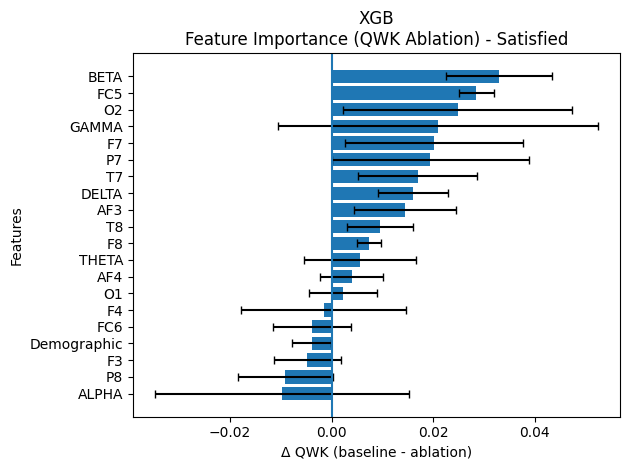

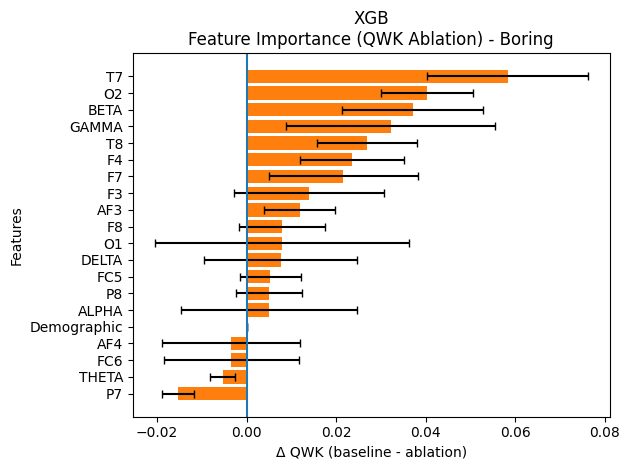

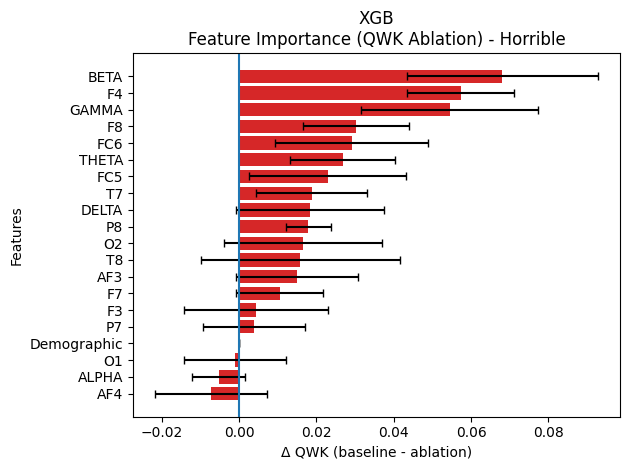

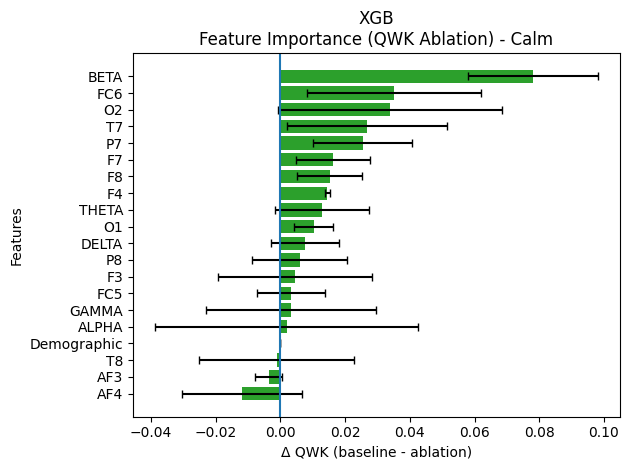

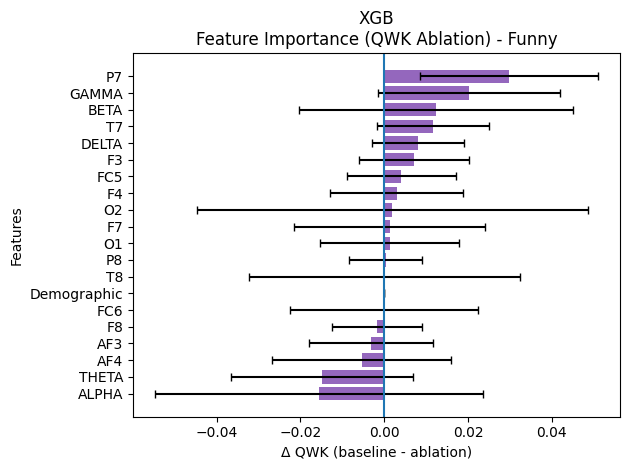

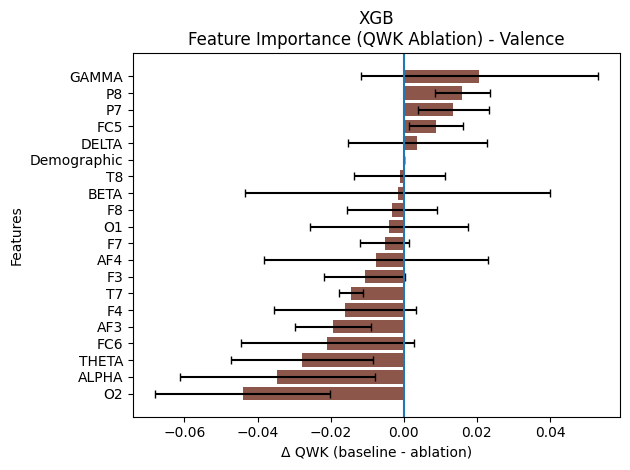

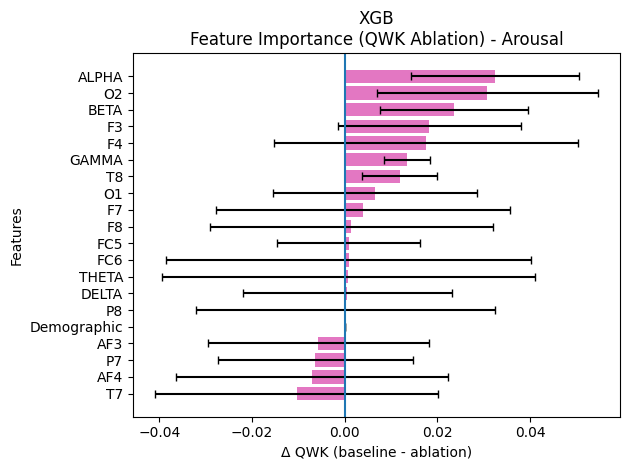

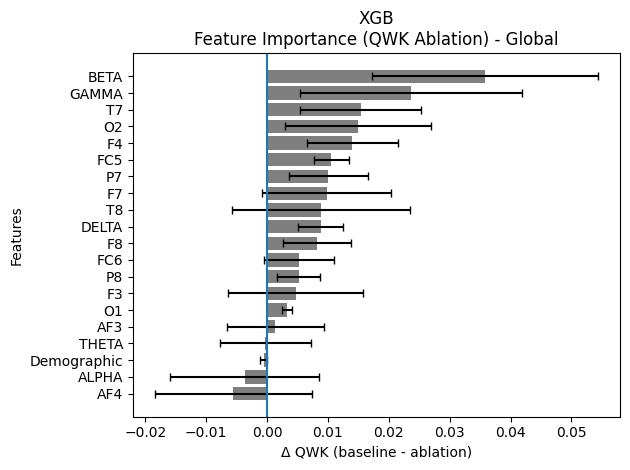

0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0


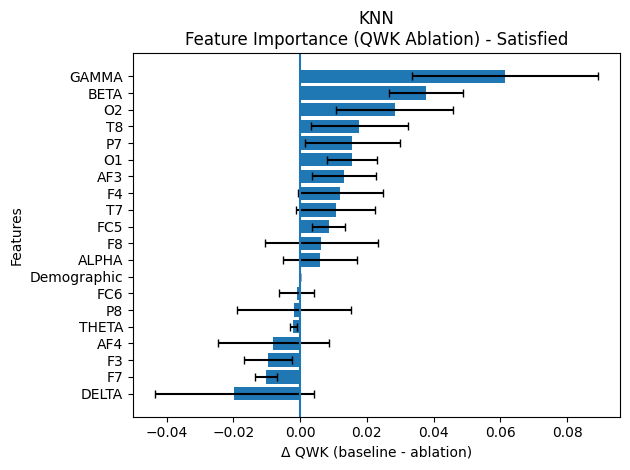

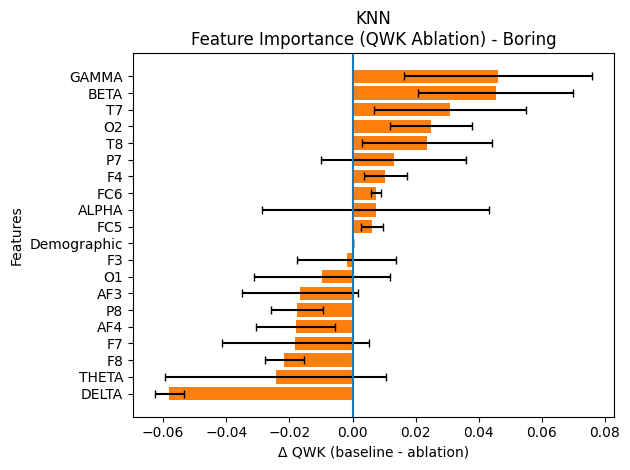

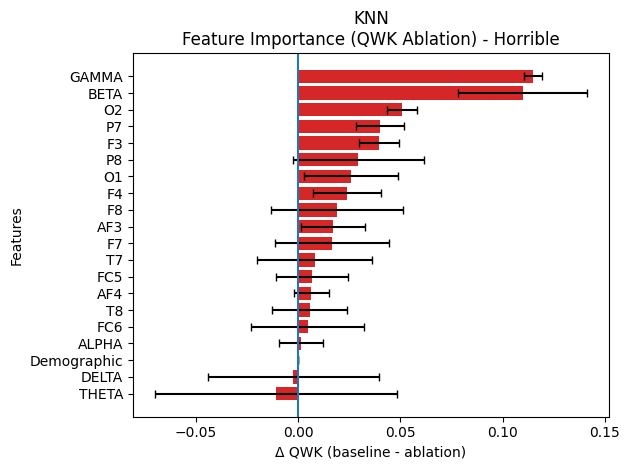

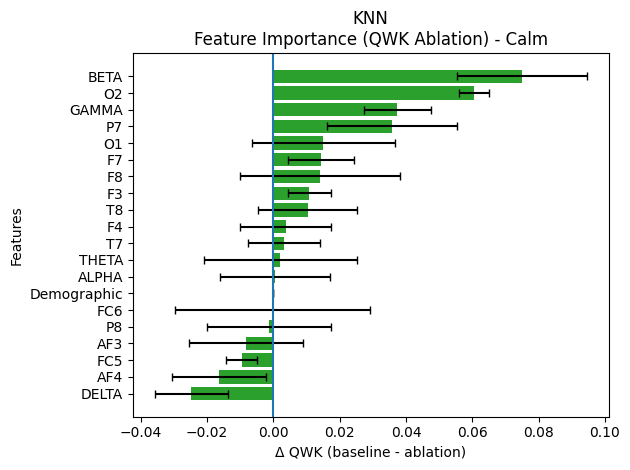

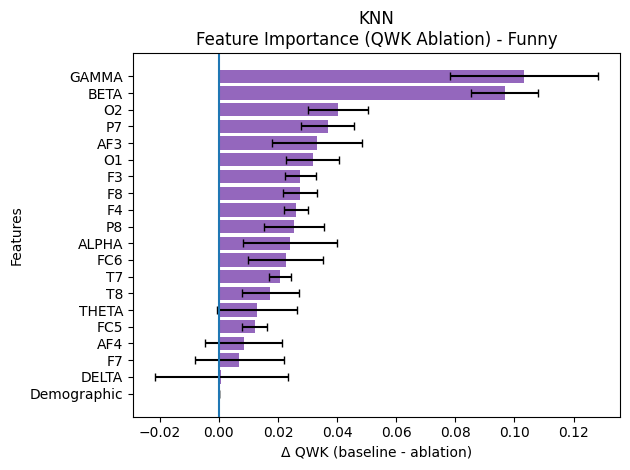

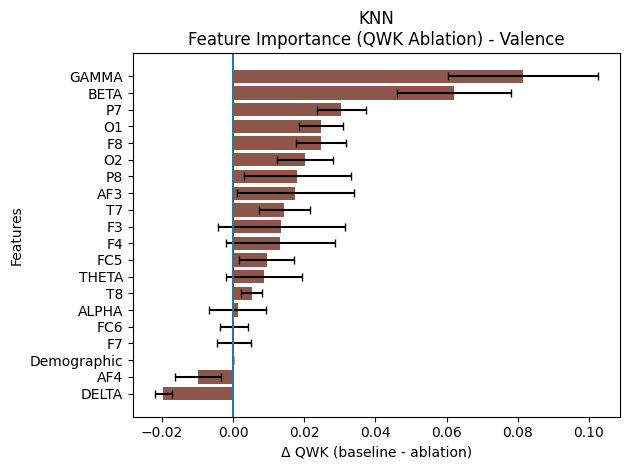

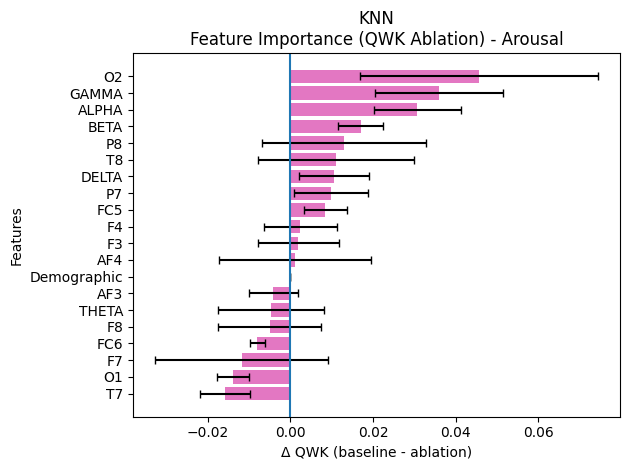

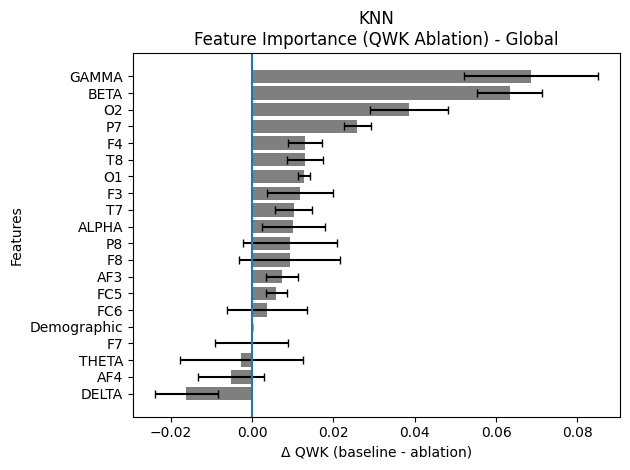

In [218]:
os.makedirs("Ablation", exist_ok=True)

target_colors = {
    "global": "#7f7f7f",
    "satisfied": "#1f77b4",  
    "boring": "#ff7f0e",    
    "horrible": "#d62728",   
    "calm": "#2ca02c",      
    "funny": "#9467bd",      
    "valence": "#8c564b",    
    "arousal": "#e377c2"   
}

def clean_feature_name(name):
    if name.startswith("remove_"):
        return name.replace("remove_", "").upper()
    elif name.startswith("no_"):
        return name.replace("no_", "").capitalize()
    else:
        return name.upper()
    
def plotAblationTarget(mean_df, std_df, model_name, target, save=True):
    
    df_plot = mean_df.sort_values(by=target, ascending=True)
    std_plot = std_df.loc[df_plot.index]

    plt.figure()
    
    plt.barh(
        df_plot.index,
        df_plot[target],
        xerr=std_plot[target],   # 🔥 intervalo de confiança (1 std)
        color=target_colors.get(target, "black"),
        capsize=3               # 🔥 deixa visual melhor
    )
    
    plt.title(f"{model_name}\nFeature Importance (QWK Ablation) - {target.capitalize()}")
    plt.xlabel("Δ QWK (baseline - ablation)")
    plt.ylabel("Features")
    plt.axvline(0)
    plt.tight_layout()
    
    if save:
        plt.savefig(f"Ablation/{model_name}_{target}.png", dpi=300)
    
    plt.show()
    plt.close()

dfs_data_ablation = {}

for model in importance_all.keys():

    data_mean = {}
    data_std = {}

    for ablation in importance_all[model]:
        
        if "only_" in ablation:
            continue
        data_mean[ablation] = {}
        data_std[ablation] = {}
        
        for target in importance_all[model][ablation]:
            
            data_mean[ablation][target] = importance_all[model][ablation][target]["mean"]
            data_std[ablation][target] = importance_all[model][ablation][target]["std"]

    mean_df = pd.DataFrame(data_mean).T
    std_df  = pd.DataFrame(data_std).T

    # limpar nomes
    mean_df.index = [clean_feature_name(i) for i in mean_df.index]
    std_df.index  = mean_df.index

    for target in mean_df.columns:
        plotAblationTarget(mean_df, std_df, model, target)

    dfs_data_ablation[f'{model}_mean'] = mean_df
    dfs_data_ablation[f'{model}_std'] = std_df

In [ ]:
for data in dfs_data_ablation.keys():
    dfs_data_ablation[data].to_pickle('ablation_' + data+'.pkl')

In [220]:
dfs_data_ablation['XGB_mean']['global']

Demographic   -0.000558
DELTA          0.008838
THETA         -0.000290
ALPHA         -0.003706
BETA           0.035806
GAMMA          0.023628
AF3            0.001349
AF4           -0.005528
F3             0.004685
F4             0.014027
F7             0.009794
F8             0.008199
FC5            0.010556
FC6            0.005263
O1             0.003309
O2             0.014888
P7             0.010070
P8             0.005200
T7             0.015353
T8             0.008854
Name: global, dtype: float64

Final Adjustments

In [256]:
#Remove Demo, Alpha e AF4

cols_to_remove = []
demo_features = ["male","female","age"]
cols_to_remove.extend([c for c in demo_features if c in df_features.columns])


cols_to_remove.extend([c for c in df_features.columns if "_alpha" in c])


cols_to_remove.extend([c for c in df_features.columns if c.startswith("AF4")])

cols_to_remove = list(set(cols_to_remove))

df_filtered = df_features.drop(columns=cols_to_remove)

In [ ]:


filtered_seeds = {}

base_model = XGBRegressor(learning_rate=0.1, max_depth=6, n_estimators=300, n_jobs= None) 

for seed in seeds:

    filtered_seeds[seed] = {}
    set_seed(seed)

    model = clone(base_model)

    dfs, metrics = LOSOCV(
        model,
        df_filtered,
        df_labels,
        metric_list,
        seed=seed
    )

    filtered_seeds[seed] = metrics


Targets:   0%|          | 0/7 [00:00<?, ?it/s]

Subjects:   0%|          | 0/28 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [242]:
filtered_qwk = {}
for target in df_labels.columns:
    filtered_qwk[target] = {}
    seed_values = []
    for seed in seeds:
        value = filtered_seeds[seed][target]['qwk']['mean']
        seed_values.append(value)
    filtered_qwk[target]['mean'] = np.mean(seed_values)
    filtered_qwk[target]['std'] = np.std(seed_values)

for target in df_labels.columns:
    print(f"{target} - {filtered_qwk[target]['mean']} +- {filtered_qwk[target]['std']}")

satisfied - 0.2547639208607712 +- 0.026175469901458474
boring - 0.38580128085026616 +- 0.026498732579598023
horrible - 0.40494486017968073 +- 0.02179411391671413
calm - 0.2271774627955466 +- 0.04019760748236717
funny - 0.3416543654244242 +- 0.03344199405568481
valence - 0.2360378629656297 +- 0.02382671953882988
arousal - 0.12108858105536058 +- 0.006302368163700176


In [ ]:
df

Final Model


In [285]:
#Save Model
set_seed(13)


final_df = df_filtered
#S28 para plataforma de teste
test_subject = 'S28'

final_dir = Path('Final')
final_dir.mkdir(parents=True,exist_ok=True)

final_model = XGBRegressor(learning_rate=0.1, max_depth=6, n_estimators=300, n_jobs= None)
for target in df_labels.columns:

    X_train = final_df.drop(test_subject, level=0)
    y_train = df_labels.drop(test_subject, level=0)[target]

    X_train = np.array(X_train)
    y_train = np.array(y_train)
    
    model_fold = clone(final_model)

    model_fold.fit(X_train, y_train)
    
    file_path = final_dir / f"final_{target}.pkl"
    with open(file_path, "wb") as f:
        pickle.dump(model_fold, f)
    

## Fontes

[1] https://www.ncbi.nlm.nih.gov/books/NBK390342/?utm_source=chatgpt.com

In [253]:
import os
LABELS = ["satisfied", "boring", "horrible", "calm", "funny", "valence", "arousal"]

BASE_DIR = os.path.dirname(os.path.abspath('GAMEEMO_app.ipynb'))

models = {}

for label in LABELS:
    path = os.path.join(BASE_DIR, "Final", f"final_{label}.pkl")
    with open(path, "rb") as f:
        models[label] = pickle.load(f)

print(models.keys())

dict_keys(['satisfied', 'boring', 'horrible', 'calm', 'funny', 'valence', 'arousal'])
